# Trend Ratio & Variance Contribution Ratio

## Daily vs. Weekly Sampled Volatility Measurement

**The problem:** A stock grinds up 25% over a month. Daily realized vol reads 45% annualized — benign. But implied vol prices 55%. Who's right?

The daily estimator is missing the trend because no single daily return is large, even though the cumulative displacement is enormous. This is the frog-in-boiling-water problem applied to vol measurement.

This notebook constructs two measures that decompose this phenomenon:

- **Trend Ratio (TR)** = RV20\_weekly / RV20\_daily — when TR > 1, the market has been trending faster than its daily noise would suggest
- **Variance Contribution Ratio (VCR20)** = max(r²) / sum(r²) over 20 daily returns — isolates whether elevated TR is driven by a grinding trend (low VCR) or a single spike day (high VCR)

### The 2×2 Framework

| | Low VCR (no single spike) | High VCR (one day dominates) |
|---|---|---|
| **TR > 1 (trending)** | Grinding Trend — frog is boiling slowly | Single Spike — event-driven |
| **TR < 1 (choppy)** | Normal — balanced daily noise | Spike was mean-reverting |

### Research Questions

1. Does TR systematically predict forward realized volatility?
2. Does VCR interact with the TR signal?
3. After a grinding trend (high TR, low VCR), does subsequent VCR *explode*? (Momentum crash hypothesis)
4. Is implied vol a superior estimator when it diverges from daily RV during grinding trends?

---


In [1]:
# Install yfinance if not already available
# On Windows, use: !py -m pip install yfinance -q
!pip install yfinance -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\kpa32\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Configuration

**Edit this cell to customize the analysis.** Change the ticker universe, date range, or rolling window parameters.


In [2]:
# ======================================================================
#  CONFIGURATION — edit these to customize the analysis
# ======================================================================

# -- Ticker Universe ---------------------------------------------------
TICKERS = [
    # US Broad Equity
    'SPY', 'RSP', 'QQQ', 'IWM', 'VTI',
    # US Sectors
    'XLF', 'XLI', 'XLP', 'XLU', 'XLV', 'XLY', 'XLE', 'XBI', 'XHB', 'XRT', 'SMH',
    # International Equity
    'EEM', 'EFA', 'EWJ', 'FEZ', 'ASHR', 'FXI', 'EWY',
    # Fixed Income
    'TLT', 'IEF', 'HYG',
    # Real Estate
    'IYR', 'VNQ',
    # Commodities
    'GLD', 'SLV', 'GDX', 'USO', 'UNG',
    # Currencies
    'FXE', 'FXY',
]

# -- Date Range --------------------------------------------------------
START_DATE = '2015-01-01'
END_DATE   = None  # None = latest available

# -- Rolling Window Parameters -----------------------------------------
WINDOW       = 20    # Rolling window in trading days
WEEKLY_FREQ  = 5     # Sub-sampling frequency for weekly returns

# -- Annualization -----------------------------------------------------
ANN_DAILY  = 252
ANN_WEEKLY = 52

# -- Asset Class Labels ------------------------------------------------
ASSET_CLASS = {
    'SPY': 'US Equity',  'RSP': 'US Equity',  'QQQ': 'US Equity',
    'IWM': 'US Equity',  'VTI': 'US Equity',
    'XLF': 'Sector',     'XLI': 'Sector',     'XLP': 'Sector',
    'XLU': 'Sector',     'XLV': 'Sector',     'XLY': 'Sector',
    'XLE': 'Sector',     'XBI': 'Sector',     'XHB': 'Sector',
    'XRT': 'Sector',     'SMH': 'Sector',
    'EEM': 'Intl Equity', 'EFA': 'Intl Equity', 'EWJ': 'Intl Equity',
    'FEZ': 'Intl Equity', 'ASHR': 'Intl Equity', 'FXI': 'Intl Equity',
    'EWY': 'Intl Equity',
    'TLT': 'Fixed Income', 'IEF': 'Fixed Income', 'HYG': 'Fixed Income',
    'IYR': 'Real Estate',  'VNQ': 'Real Estate',
    'GLD': 'Commodity',  'SLV': 'Commodity',  'GDX': 'Commodity',
    'USO': 'Commodity',  'UNG': 'Commodity',
    'FXE': 'Currency',   'FXY': 'Currency',
}

print(f"Universe: {len(TICKERS)} tickers")
print(f"Date range: {START_DATE} to {END_DATE or 'latest'}")
print(f"Rolling window: {WINDOW} days, weekly sub-sample every {WEEKLY_FREQ} days")


Universe: 35 tickers
Date range: 2015-01-01 to latest
Rolling window: 20 days, weekly sub-sample every 5 days


## 2. Setup

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = {
    'primary': '#00C4E7',
    'secondary': '#F6852B',
    'accent': '#182B40',
    'neutral': '#5A5A5A',
    'bg': '#F6F4EE',
    'green': '#6DF2A1',
    'gold': '#F7C940',
    'pink': '#EC3586',
}

REGIME_COLORS = {
    'Grinding Trend': '#00C4E7',
    'Spike Trend':    '#EC3586',
    'Choppy Grind':   '#5A5A5A',
    'Spike Revert':   '#F7C940',
}


## 3. Fetch Price Data

Downloads adjusted close prices for all tickers. This is the only external data dependency.


In [4]:
def fetch_prices(tickers, start, end=None):
    """Download adjusted close prices via yfinance."""
    print(f"Fetching {len(tickers)} tickers from Yahoo Finance...")
    
    try:
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=True)
        
        if isinstance(raw.columns, pd.MultiIndex):
            prices = raw['Close']
        else:
            prices = raw[['Close']]
            prices.columns = tickers
        
        failed = [t for t in tickers if t not in prices.columns or prices[t].isna().all()]
        if failed:
            print(f"Warning: failed to fetch: {failed}")
            prices = prices.drop(columns=failed, errors='ignore')
        
        prices = prices.dropna(how='all')
        
        if prices.empty:
            print("Error: No data fetched successfully for any ticker")
            print("This appears to be a Yahoo Finance API issue.")
            print("Try running the notebook again later or check your internet connection.")
            return pd.DataFrame()
        
        print(f"Fetched {prices.shape[1]} tickers, {prices.shape[0]} trading days")
        print(f"  {prices.index[0].date()} to {prices.index[-1].date()}")
        return prices
        
    except Exception as e:
        print(f"Error fetching data: {e}")
        print("This appears to be a Yahoo Finance API issue.")
        print("Please try again later or use an alternative data source.")
        return pd.DataFrame()

        print("Please try again later or use an alternative data source.")
        return pd.DataFrame()

prices = fetch_prices(TICKERS, START_DATE, END_DATE)

# Exit early if no data was fetched
if prices.empty:
    print("\n⚠️  Cannot proceed without price data.")

Fetching 35 tickers from Yahoo Finance...


[*********************100%***********************]  35 of 35 completed

Fetched 35 tickers, 2808 trading days
  2015-01-02 to 2026-03-04


## 4. Variable Construction

All variables computed from close-to-close log returns over a rolling window.

| Variable | Formula | Annualization |
|---|---|---|
| RV20\_daily | `sqrt(sum(r_i²) / N)` over N daily log returns | `× sqrt(252)` |
| RV20\_weekly | `sqrt(sum(R_j²) / K)` over K weekly log returns from same window | `× sqrt(52)` |
| TR | `RV20_weekly / RV20_daily` | dimensionless |
| VCR20 | `max(r_i²) / sum(r_i²)` | percentage |

Zero-mean estimator (dividing by N, not N-1) is deliberate: it measures total quadratic variation including drift.


In [5]:
def compute_panel(prices, window=WINDOW, weekly_freq=WEEKLY_FREQ,
                   ann_daily=ANN_DAILY, ann_weekly=ANN_WEEKLY):
    """
    Compute RV20_daily, RV20_weekly, TR, and VCR20 from close prices.
    """
    n_weekly = window // weekly_freq
    all_rows = []

    for ticker in prices.columns:
        px = prices[ticker].dropna()
        if len(px) < window + 1:
            print(f"  {ticker}: insufficient data, skipping")
            continue

        close_arr = px.values
        log_ret = np.log(px / px.shift(1)).dropna()
        ret_arr = log_ret.values
        ret_dates = log_ret.index

        for i in range(window, len(ret_arr)):
            daily_rets = ret_arr[i - window : i]

            # RV20 daily (annualized %)
            rv_daily = np.sqrt(np.sum(daily_rets**2) / window) * np.sqrt(ann_daily) * 100

            # Weekly returns from same window
            weekly_closes_idx = list(range(i - window, i + 1, weekly_freq))
            if len(weekly_closes_idx) < n_weekly + 1:
                continue
            weekly_closes = close_arr[weekly_closes_idx]
            weekly_rets = np.log(weekly_closes[1:] / weekly_closes[:-1])

            # RV20 weekly (annualized %)
            rv_weekly = np.sqrt(np.sum(weekly_rets**2) / n_weekly) * np.sqrt(ann_weekly) * 100

            tr = rv_weekly / rv_daily if rv_daily > 0 else np.nan

            sum_sq = np.sum(daily_rets**2)
            vcr = (np.max(daily_rets**2) / sum_sq * 100) if sum_sq > 0 else np.nan

            all_rows.append({
                'ticker': ticker, 'date': ret_dates[i],
                'rv20_daily': rv_daily, 'rv20_weekly': rv_weekly,
                'TR': tr, 'vcr20': vcr,
            })

    panel = pd.DataFrame(all_rows)
    panel['date'] = pd.to_datetime(panel['date'])
    return panel

print("Computing rolling volatility measures...")
panel = compute_panel(prices)
print(f"\nPanel: {panel.shape[0]:,} observations")
print(f"  {panel.ticker.nunique()} tickers x ~{panel.groupby('ticker').size().median():.0f} days each")
print(f"  {panel.date.min().date()} to {panel.date.max().date()}")


Computing rolling volatility measures...

Panel: 97,545 observations
  35 tickers x ~2787 days each
  2015-02-03 to 2026-03-04


## 5. Data Validation

In [6]:
print("Missing values:")
print(panel[['rv20_daily', 'rv20_weekly', 'TR', 'vcr20']].isnull().sum().to_string())
print(f"\nInf in TR: {np.isinf(panel['TR']).sum()}")
print(f"\nRanges:")
print(f"  RV20 daily:  [{panel.rv20_daily.min():.1f}%, {panel.rv20_daily.max():.1f}%]  med = {panel.rv20_daily.median():.1f}%")
print(f"  RV20 weekly: [{panel.rv20_weekly.min():.1f}%, {panel.rv20_weekly.max():.1f}%]  med = {panel.rv20_weekly.median():.1f}%")
print(f"  TR:          [{panel.TR.min():.3f}, {panel.TR.max():.3f}]  med = {panel.TR.median():.3f}")
print(f"  VCR20:       [{panel.vcr20.min():.1f}%, {panel.vcr20.max():.1f}%]  med = {panel.vcr20.median():.1f}%")

obs = panel.groupby('ticker').size()
print(f"\nObs per ticker: min={obs.min()}, max={obs.max()}")


Missing values:
rv20_daily     0
rv20_weekly    0
TR             0
vcr20          0

Inf in TR: 0

Ranges:
  RV20 daily:  [1.5%, 176.8%]  med = 16.3%
  RV20 weekly: [0.4%, 248.1%]  med = 14.9%
  TR:          [0.022, 2.056]  med = 0.947
  VCR20:       [8.7%, 84.8%]  med = 25.2%

Obs per ticker: min=2787, max=2787


## 6. Universe Overview — Per-Ticker Distributions

In [ ]:
def ticker_summary(panel):
    rows = []
    for ticker, g in panel.groupby('ticker'):
        rows.append({
            'ticker': ticker,
            'asset_class': ASSET_CLASS.get(ticker, '?'),
            'obs': len(g),
            # RV20 daily
            'RV20d Mean%': g.rv20_daily.mean(),
            'RV20d Std': g.rv20_daily.std(),
            'RV20d p05': np.percentile(g.rv20_daily, 5),
            'RV20d p25': np.percentile(g.rv20_daily, 25),
            'RV20d Med': g.rv20_daily.median(),
            'RV20d p75': np.percentile(g.rv20_daily, 75),
            'RV20d p95': np.percentile(g.rv20_daily, 95),
            'RV20d p99': np.percentile(g.rv20_daily, 99),
            # RV20 weekly
            'RV20w Mean%': g.rv20_weekly.mean(),
            'RV20w Med': g.rv20_weekly.median(),
            # Trend Ratio
            'TR Mean': g.TR.mean(),
            'TR Std': g.TR.std(),
            'TR p05': np.percentile(g.TR, 5),
            'TR p25': np.percentile(g.TR, 25),
            'TR Med': g.TR.median(),
            'TR p75': np.percentile(g.TR, 75),
            'TR p95': np.percentile(g.TR, 95),
            'TR p99': np.percentile(g.TR, 99),
            # VCR20
            'VCR20 Mean%': g.vcr20.mean(),
            'VCR20 Std': g.vcr20.std(),
            'VCR20 p05': np.percentile(g.vcr20, 5),
            'VCR20 p25': np.percentile(g.vcr20, 25),
            'VCR20 Med': g.vcr20.median(),
            'VCR20 p75': np.percentile(g.vcr20, 75),
            'VCR20 p95': np.percentile(g.vcr20, 95),
            'VCR20 p99': np.percentile(g.vcr20, 99),
        })
    return pd.DataFrame(rows).sort_values('RV20d Med').reset_index(drop=True)

ts = ticker_summary(panel)

# Display compact view (key columns)
display_cols = ['ticker', 'asset_class', 'obs', 'RV20d Med', 'RV20w Med',
                'TR Med', 'TR p95', 'VCR20 Med', 'VCR20 p95']
print(ts[display_cols].to_string(index=False, float_format='{:.2f}'.format))

ticker  asset_class  obs  RV20d Med  RV20w Med  TR Med  TR p95  VCR20 Med  VCR20 p95
   HYG Fixed Income 2787       5.08       4.64    0.95    1.48      25.18      49.36
   IEF Fixed Income 2787       5.49       5.19    0.94    1.45      24.33      45.06
   FXE     Currency 2787       7.04       6.38    0.94    1.45      24.34      48.43
   FXY     Currency 2787       7.88       7.15    0.94    1.45      28.01      53.28
   XLP       Sector 2787      11.19      10.06    0.90    1.40      25.45      45.55
   SPY    US Equity 2787      12.34      11.31    0.93    1.46      24.84      50.16
   RSP    US Equity 2787      12.64      11.72    0.94    1.46      25.21      45.13
   VTI    US Equity 2787      12.68      11.76    0.95    1.46      24.45      49.12
   TLT Fixed Income 2787      12.70      11.76    0.92    1.42      23.36      42.17
   XLV       Sector 2787      12.99      12.22    0.96    1.49      24.93      43.82
   EFA  Intl Equity 2787      13.10      11.97    0.95    1.44   

## 7. Pooled Distributions — TR, VCR, and Their Relationship

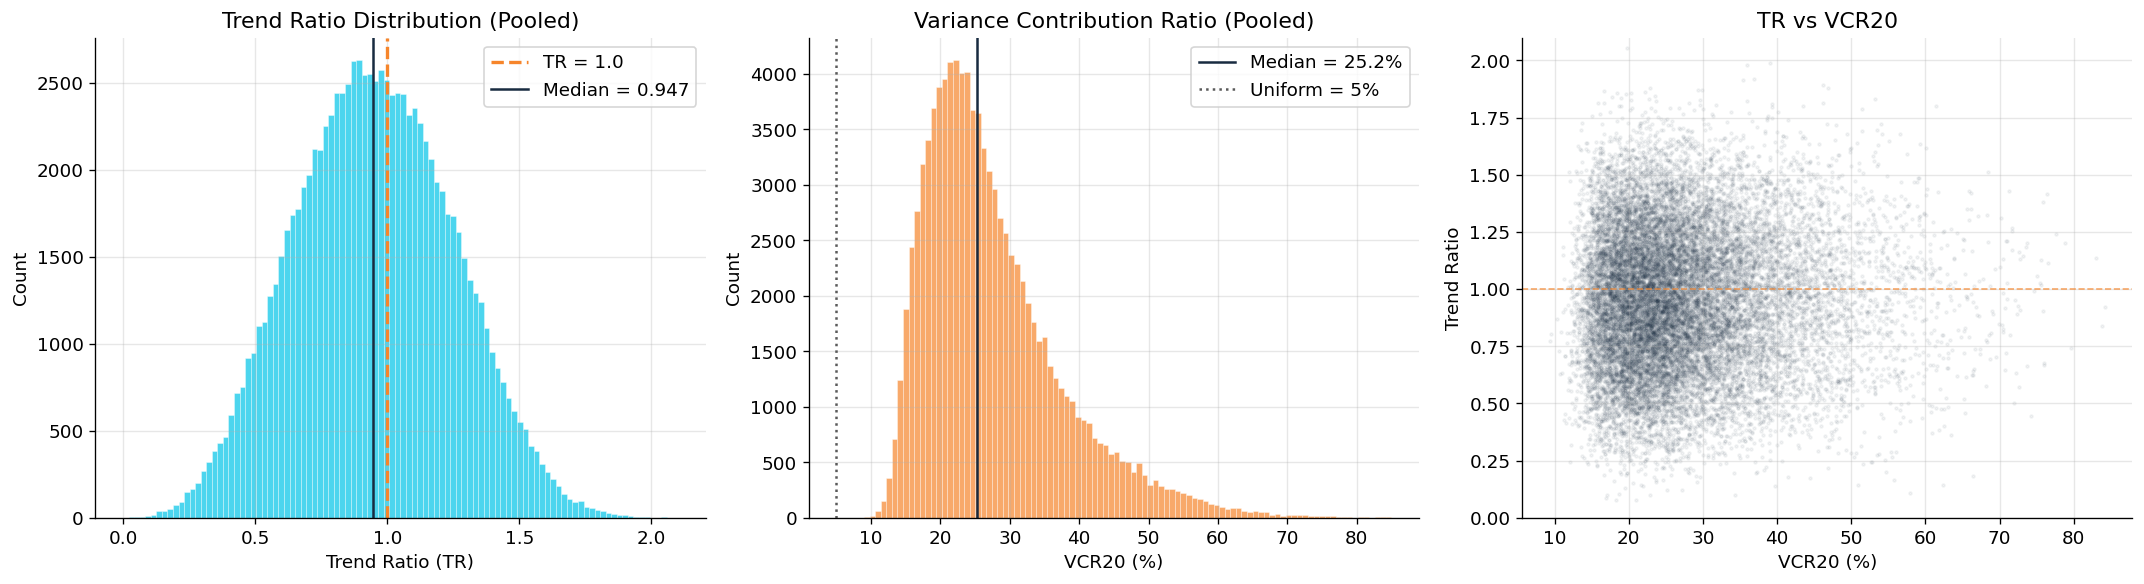


Pooled Summary:
              TR      vcr20  rv20_daily  rv20_weekly
count  97545.000  97545.000   97545.000    97545.000
mean       0.951     27.532      19.739       18.689
std        0.299     10.029      14.084       14.920
min        0.022      8.740       1.511        0.372
5%         0.465     15.562       5.680        4.357
25%        0.737     20.324      11.224        9.454
50%        0.947     25.230      16.337       14.947
75%        1.160     32.350      24.106       23.403
95%        1.449     47.659      44.234       44.568
99%        1.631     59.699      76.649       76.403
max        2.056     84.783     176.820      248.086


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(panel['TR'], bins=100, range=(0, 2.1), color=COLORS['primary'],
        alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(1.0, color=COLORS['secondary'], ls='--', lw=2, label='TR = 1.0')
ax.axvline(panel['TR'].median(), color=COLORS['accent'], ls='-', lw=1.5,
           label=f'Median = {panel["TR"].median():.3f}')
ax.set_xlabel('Trend Ratio (TR)')
ax.set_ylabel('Count')
ax.set_title('Trend Ratio Distribution (Pooled)')
ax.legend()

ax = axes[1]
ax.hist(panel['vcr20'], bins=100, range=(5, 85), color=COLORS['secondary'],
        alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(panel['vcr20'].median(), color=COLORS['accent'], ls='-', lw=1.5,
           label=f'Median = {panel["vcr20"].median():.1f}%')
ax.axvline(100 / WINDOW, color=COLORS['neutral'], ls=':', lw=1.5,
           label=f'Uniform = {100/WINDOW:.0f}%')
ax.set_xlabel('VCR20 (%)')
ax.set_ylabel('Count')
ax.set_title('Variance Contribution Ratio (Pooled)')
ax.legend()

ax = axes[2]
sample = panel.sample(n=min(20_000, len(panel)), random_state=42)
ax.scatter(sample['vcr20'], sample['TR'], alpha=0.05, s=3, color=COLORS['accent'])
ax.axhline(1.0, color=COLORS['secondary'], ls='--', lw=1, alpha=0.7)
ax.set_xlabel('VCR20 (%)')
ax.set_ylabel('Trend Ratio')
ax.set_title('TR vs VCR20')
ax.set_ylim(0, 2.1)

plt.tight_layout()
plt.show()

print("\nPooled Summary:")
print(panel[['TR', 'vcr20', 'rv20_daily', 'rv20_weekly']].describe(
    percentiles=[.05, .25, .5, .75, .95, .99]).round(3))


### Per-Ticker TR Range — Sorted by Median

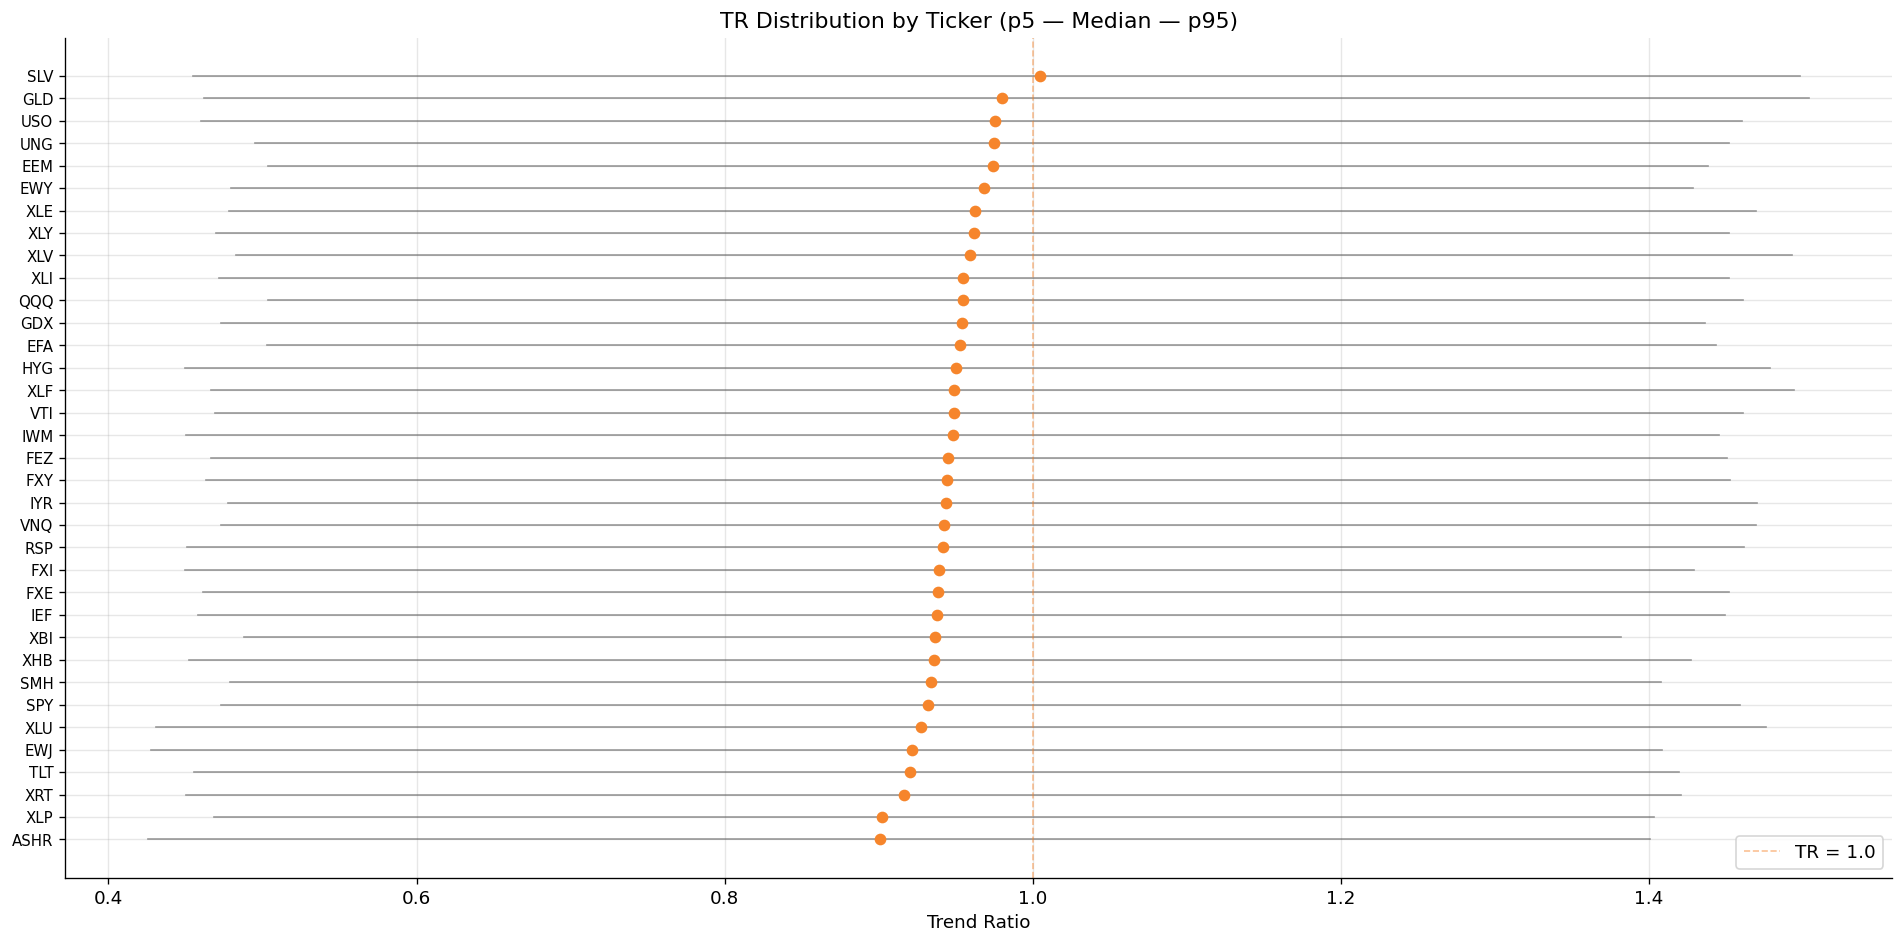

In [9]:
fig, ax = plt.subplots(figsize=(16, 8))
ts_sorted = ts.sort_values('TR Med')

for i, (_, row) in enumerate(ts_sorted.iterrows()):
    ax.plot([row['TR p05'], row['TR p95']], [i, i],
            color=COLORS['neutral'], lw=1, alpha=0.6)
    ax.plot(row['TR Med'], i, 'o', color=COLORS['secondary'], markersize=6, zorder=5)

ax.axvline(1.0, color=COLORS['secondary'], ls='--', lw=1, alpha=0.5, label='TR = 1.0')
ax.set_yticks(range(len(ts_sorted)))
ax.set_yticklabels(ts_sorted['ticker'].values, fontsize=9)
ax.set_xlabel('Trend Ratio')
ax.set_title('TR Distribution by Ticker (p5 — Median — p95)')
ax.legend()
plt.tight_layout()
plt.show()


### Per-Ticker VCR Range — Sorted by Median

KeyError: 'VCR Med'

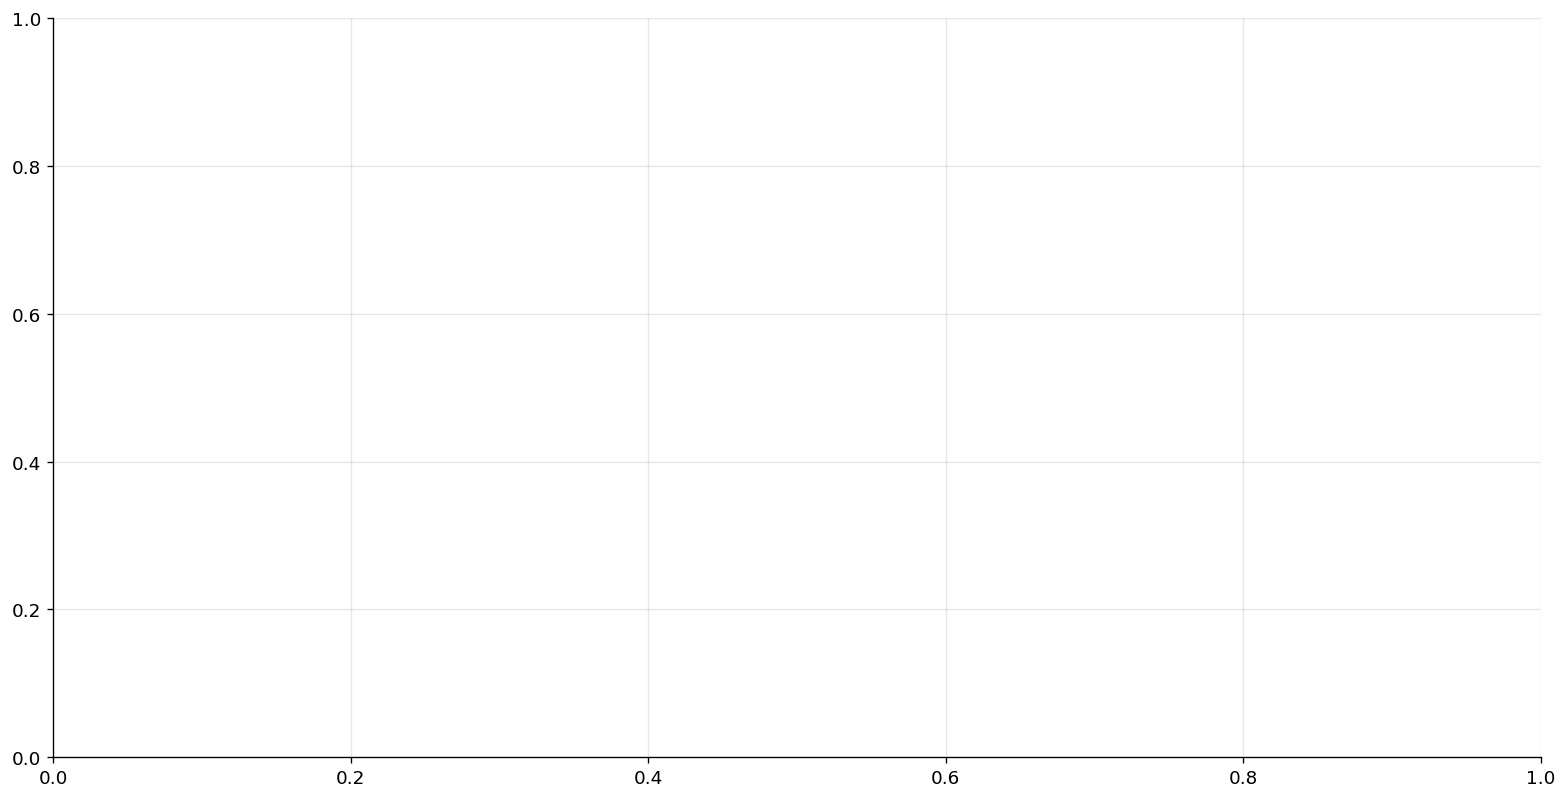

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))
ts_vcr_sorted = ts.sort_values('VCR20 Med')

for i, (_, row) in enumerate(ts_vcr_sorted.iterrows()):
    ax.plot([row['VCR20 p05'], row['VCR20 p95']], [i, i],
            color=COLORS['neutral'], lw=1, alpha=0.6)
    ax.plot(row['VCR20 Med'], i, 'o', color=COLORS['gold'], markersize=6, zorder=5)

ax.axvline(100 / WINDOW, color=COLORS['neutral'], ls=':', lw=1, alpha=0.5,
           label=f'Uniform = {100/WINDOW:.0f}%')
ax.set_yticks(range(len(ts_vcr_sorted)))
ax.set_yticklabels(ts_vcr_sorted['ticker'].values, fontsize=9)
ax.set_xlabel('VCR20 (%)')
ax.set_title('VCR20 Distribution by Ticker (p5 — Median — p95)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Time Series Case Study

Change `CASE_TICKER` to explore any ticker in the universe.


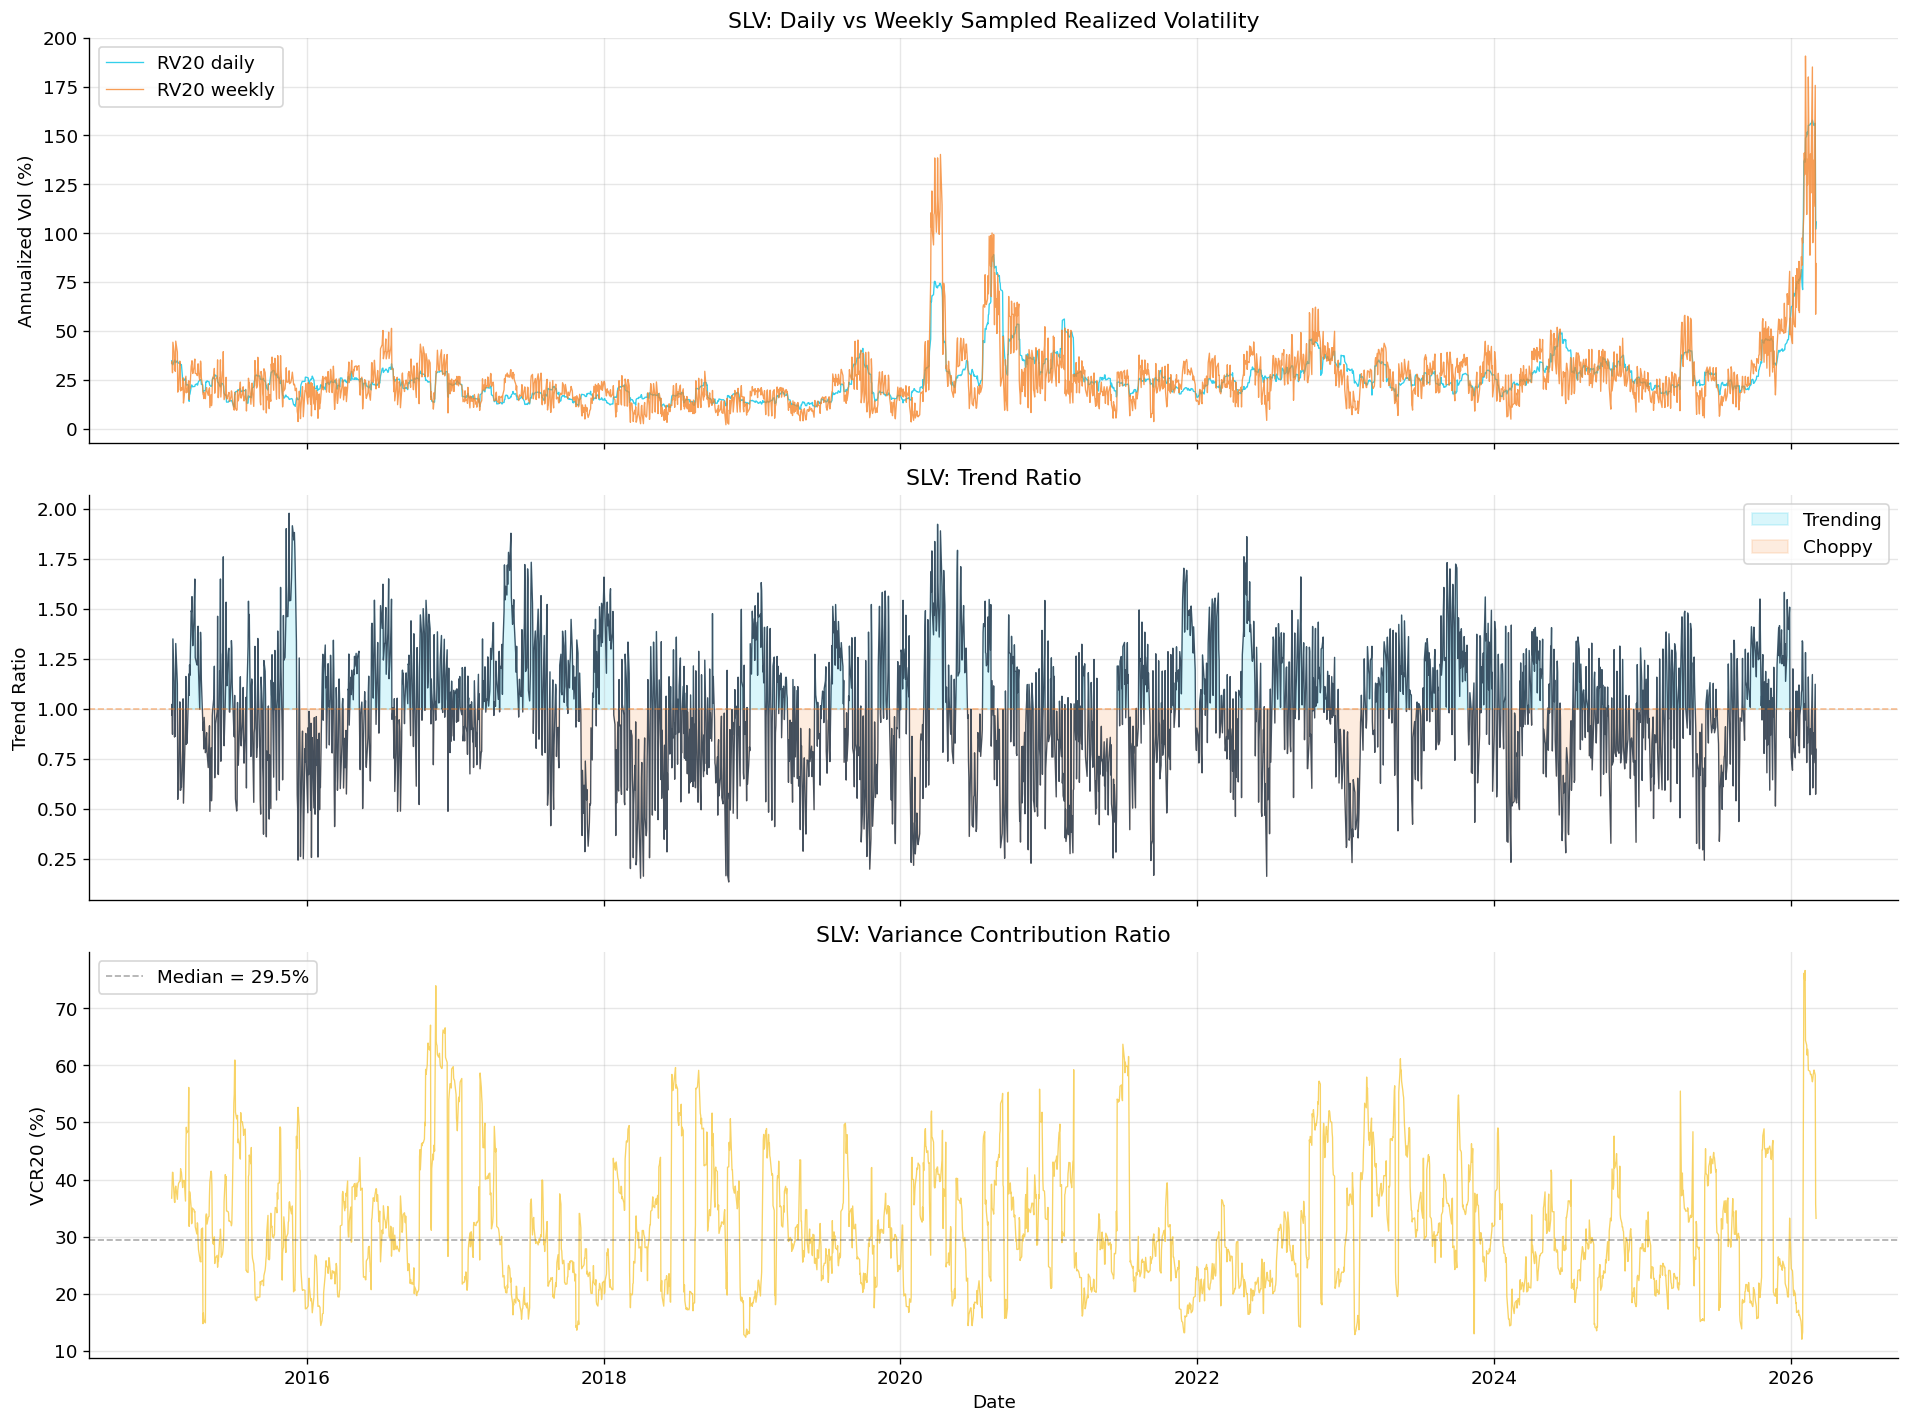

In [ ]:
CASE_TICKER = 'SLV'

case = panel[panel.ticker == CASE_TICKER].sort_values('date')
if len(case) == 0:
    print(f"{CASE_TICKER} not found in panel")
else:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    ax = axes[0]
    ax.plot(case.date, case.rv20_daily, color=COLORS['primary'], alpha=0.8, lw=0.8, label='RV20 daily')
    ax.plot(case.date, case.rv20_weekly, color=COLORS['secondary'], alpha=0.8, lw=0.8, label='RV20 weekly')
    ax.set_ylabel('Annualized Vol (%)')
    ax.set_title(f'{CASE_TICKER}: Daily vs Weekly Sampled Realized Volatility')
    ax.legend()

    ax = axes[1]
    ax.plot(case.date, case.TR, color=COLORS['accent'], alpha=0.8, lw=0.8)
    ax.axhline(1.0, color=COLORS['secondary'], ls='--', lw=1, alpha=0.5)
    ax.fill_between(case.date, case.TR, 1.0, where=(case.TR > 1),
                    color=COLORS['primary'], alpha=0.15, label='Trending')
    ax.fill_between(case.date, case.TR, 1.0, where=(case.TR < 1),
                    color=COLORS['secondary'], alpha=0.15, label='Choppy')
    ax.set_ylabel('Trend Ratio')
    ax.set_title(f'{CASE_TICKER}: Trend Ratio')
    ax.legend()

    ax = axes[2]
    ax.plot(case.date, case.vcr20, color=COLORS['gold'], alpha=0.8, lw=0.8)
    ax.axhline(case.vcr20.median(), color=COLORS['neutral'], ls='--', lw=1, alpha=0.5,
               label=f'Median = {case.vcr20.median():.1f}%')
    ax.set_ylabel('VCR20 (%)')
    ax.set_xlabel('Date')
    ax.set_title(f'{CASE_TICKER}: Variance Contribution Ratio')
    ax.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
# Compute SLV's median VCR excluding data after May 2025
slv_data = panel[panel.ticker == 'SLV'].copy()
slv_pre_may2025 = slv_data[slv_data.date <= '2025-05-31']

if len(slv_pre_may2025) > 0:
    median_vcr_pre_may2025 = slv_pre_may2025['vcr20'].median()
    median_vcr_all_time = slv_data['vcr20'].median()
    
    print(f"SLV VCR Analysis:")
    print(f"  All-time median VCR:     {median_vcr_all_time:.1f}%")
    print(f"  Pre-May 2025 median VCR: {median_vcr_pre_may2025:.1f}%")
    print(f"  Difference:              {median_vcr_all_time - median_vcr_pre_may2025:+.1f}%")
    print(f"  ")
    print(f"  Data points (all-time):  {len(slv_data):,}")
    print(f"  Data points (pre-May 25): {len(slv_pre_may2025):,}")
else:
    print("No SLV data found in the panel")

SLV VCR Analysis:
  All-time median VCR:     29.5%
  Pre-May 2025 median VCR: 29.4%
  Difference:              +0.0%
  
  Data points (all-time):  2,787
  Data points (pre-May 25): 2,597


## 9. Forward Volatility Analysis — Does TR Predict Next-Period Vol Changes?

The core question: if TR is elevated today, does realized vol *increase* in the following period relative to the current period?

We compute forward 20-day RV (both daily and weekly sampled) and measure the **percent change** from current to forward: `(fwd_rv - current_rv) / current_rv`.


In [ ]:
def add_forward_vars(group):
    group = group.sort_values('date')
    group['fwd_rv20_daily'] = group['rv20_daily'].shift(-WINDOW)
    group['fwd_rv20_weekly'] = group['rv20_weekly'].shift(-WINDOW)
    group['fwd_vcr'] = group['vcr20'].shift(-WINDOW)
    group['fwd_TR'] = group['TR'].shift(-WINDOW)
    # Percent change in RV: (forward - current) / current
    group['rv_daily_pct_chg'] = (group['fwd_rv20_daily'] - group['rv20_daily']) / group['rv20_daily'] * 100
    group['rv_weekly_pct_chg'] = (group['fwd_rv20_weekly'] - group['rv20_weekly']) / group['rv20_weekly'] * 100
    return group

panel = panel.groupby('ticker', group_keys=False).apply(add_forward_vars)
fwd = panel.dropna(subset=['fwd_rv20_daily']).copy()

print(f"Forward-valid observations: {len(fwd):,} "
      f"(dropped {len(panel) - len(fwd):,} from end of each series)")


Forward-valid observations: 96,845 (dropped 700 from end of each series)


### Forward RV Change by TR Quintile

For each TR quintile, we show the **mean percent change** in both daily-sampled and weekly-sampled RV from current to next period. If TR contains forward information, the high-TR quintiles should show systematically different forward RV behavior.


In [ ]:
fwd['TR_q'] = pd.qcut(fwd['TR'], 5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

fwd_by_tr = fwd.groupby('TR_q', observed=True).agg(
    n=('TR', 'count'),
    TR_mean=('TR', 'mean'),
    # Current RV
    cur_rv20d_mean=('rv20_daily', 'mean'),
    cur_rv20d_med=('rv20_daily', 'median'),
    cur_rv20d_std=('rv20_daily', 'std'),
    # Forward RV
    fwd_rv20d_mean=('fwd_rv20_daily', 'mean'),
    fwd_rv20d_med=('fwd_rv20_daily', 'median'),
    fwd_rv20d_std=('fwd_rv20_daily', 'std'),
    # RV daily % change
    rv_daily_chg_mean=('rv_daily_pct_chg', 'mean'),
    rv_daily_chg_med=('rv_daily_pct_chg', 'median'),
    rv_daily_chg_std=('rv_daily_pct_chg', 'std'),
    # Weekly
    cur_rv20w_mean=('rv20_weekly', 'mean'),
    fwd_rv20w_mean=('fwd_rv20_weekly', 'mean'),
    rv_weekly_chg_mean=('rv_weekly_pct_chg', 'mean'),
    rv_weekly_chg_med=('rv_weekly_pct_chg', 'median'),
).round(2)

print("Forward RV Change by TR Quintile:\n")
print(fwd_by_tr.to_string())
print("\n\nForward RV20 Daily — Mean vs Median by Quintile:\n")
for q in ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']:
    row = fwd_by_tr.loc[q]
    print(f"  {q}:  current mean={row.cur_rv20d_mean:.1f}%  med={row.cur_rv20d_med:.1f}%  std={row.cur_rv20d_std:.1f}"
          f"  →  fwd mean={row.fwd_rv20d_mean:.1f}%  med={row.fwd_rv20d_med:.1f}%  std={row.fwd_rv20d_std:.1f}"
          f"  |  chg mean={row.rv_daily_chg_mean:+.1f}%  med={row.rv_daily_chg_med:+.1f}%  std={row.rv_daily_chg_std:.1f}")

Forward RV Change by TR Quintile:

               n  TR_mean  cur_rv20d_mean  cur_rv20d_med  cur_rv20d_std  fwd_rv20d_mean  fwd_rv20d_med  fwd_rv20d_std  rv_daily_chg_mean  rv_daily_chg_med  rv_daily_chg_std  cur_rv20w_mean  fwd_rv20w_mean  rv_weekly_chg_mean  rv_weekly_chg_med
TR_q                                                                                                                                                                                                                                               
Q1 (Low)   19369     0.54           19.56          16.21          13.67           18.86          15.80          12.83               4.63             -3.39             47.92           10.52           18.13              103.94              69.99
Q2         19369     0.78           19.95          16.66          13.67           19.43          16.21          13.45               4.76             -3.25             46.20           15.62           18.48               28.58         

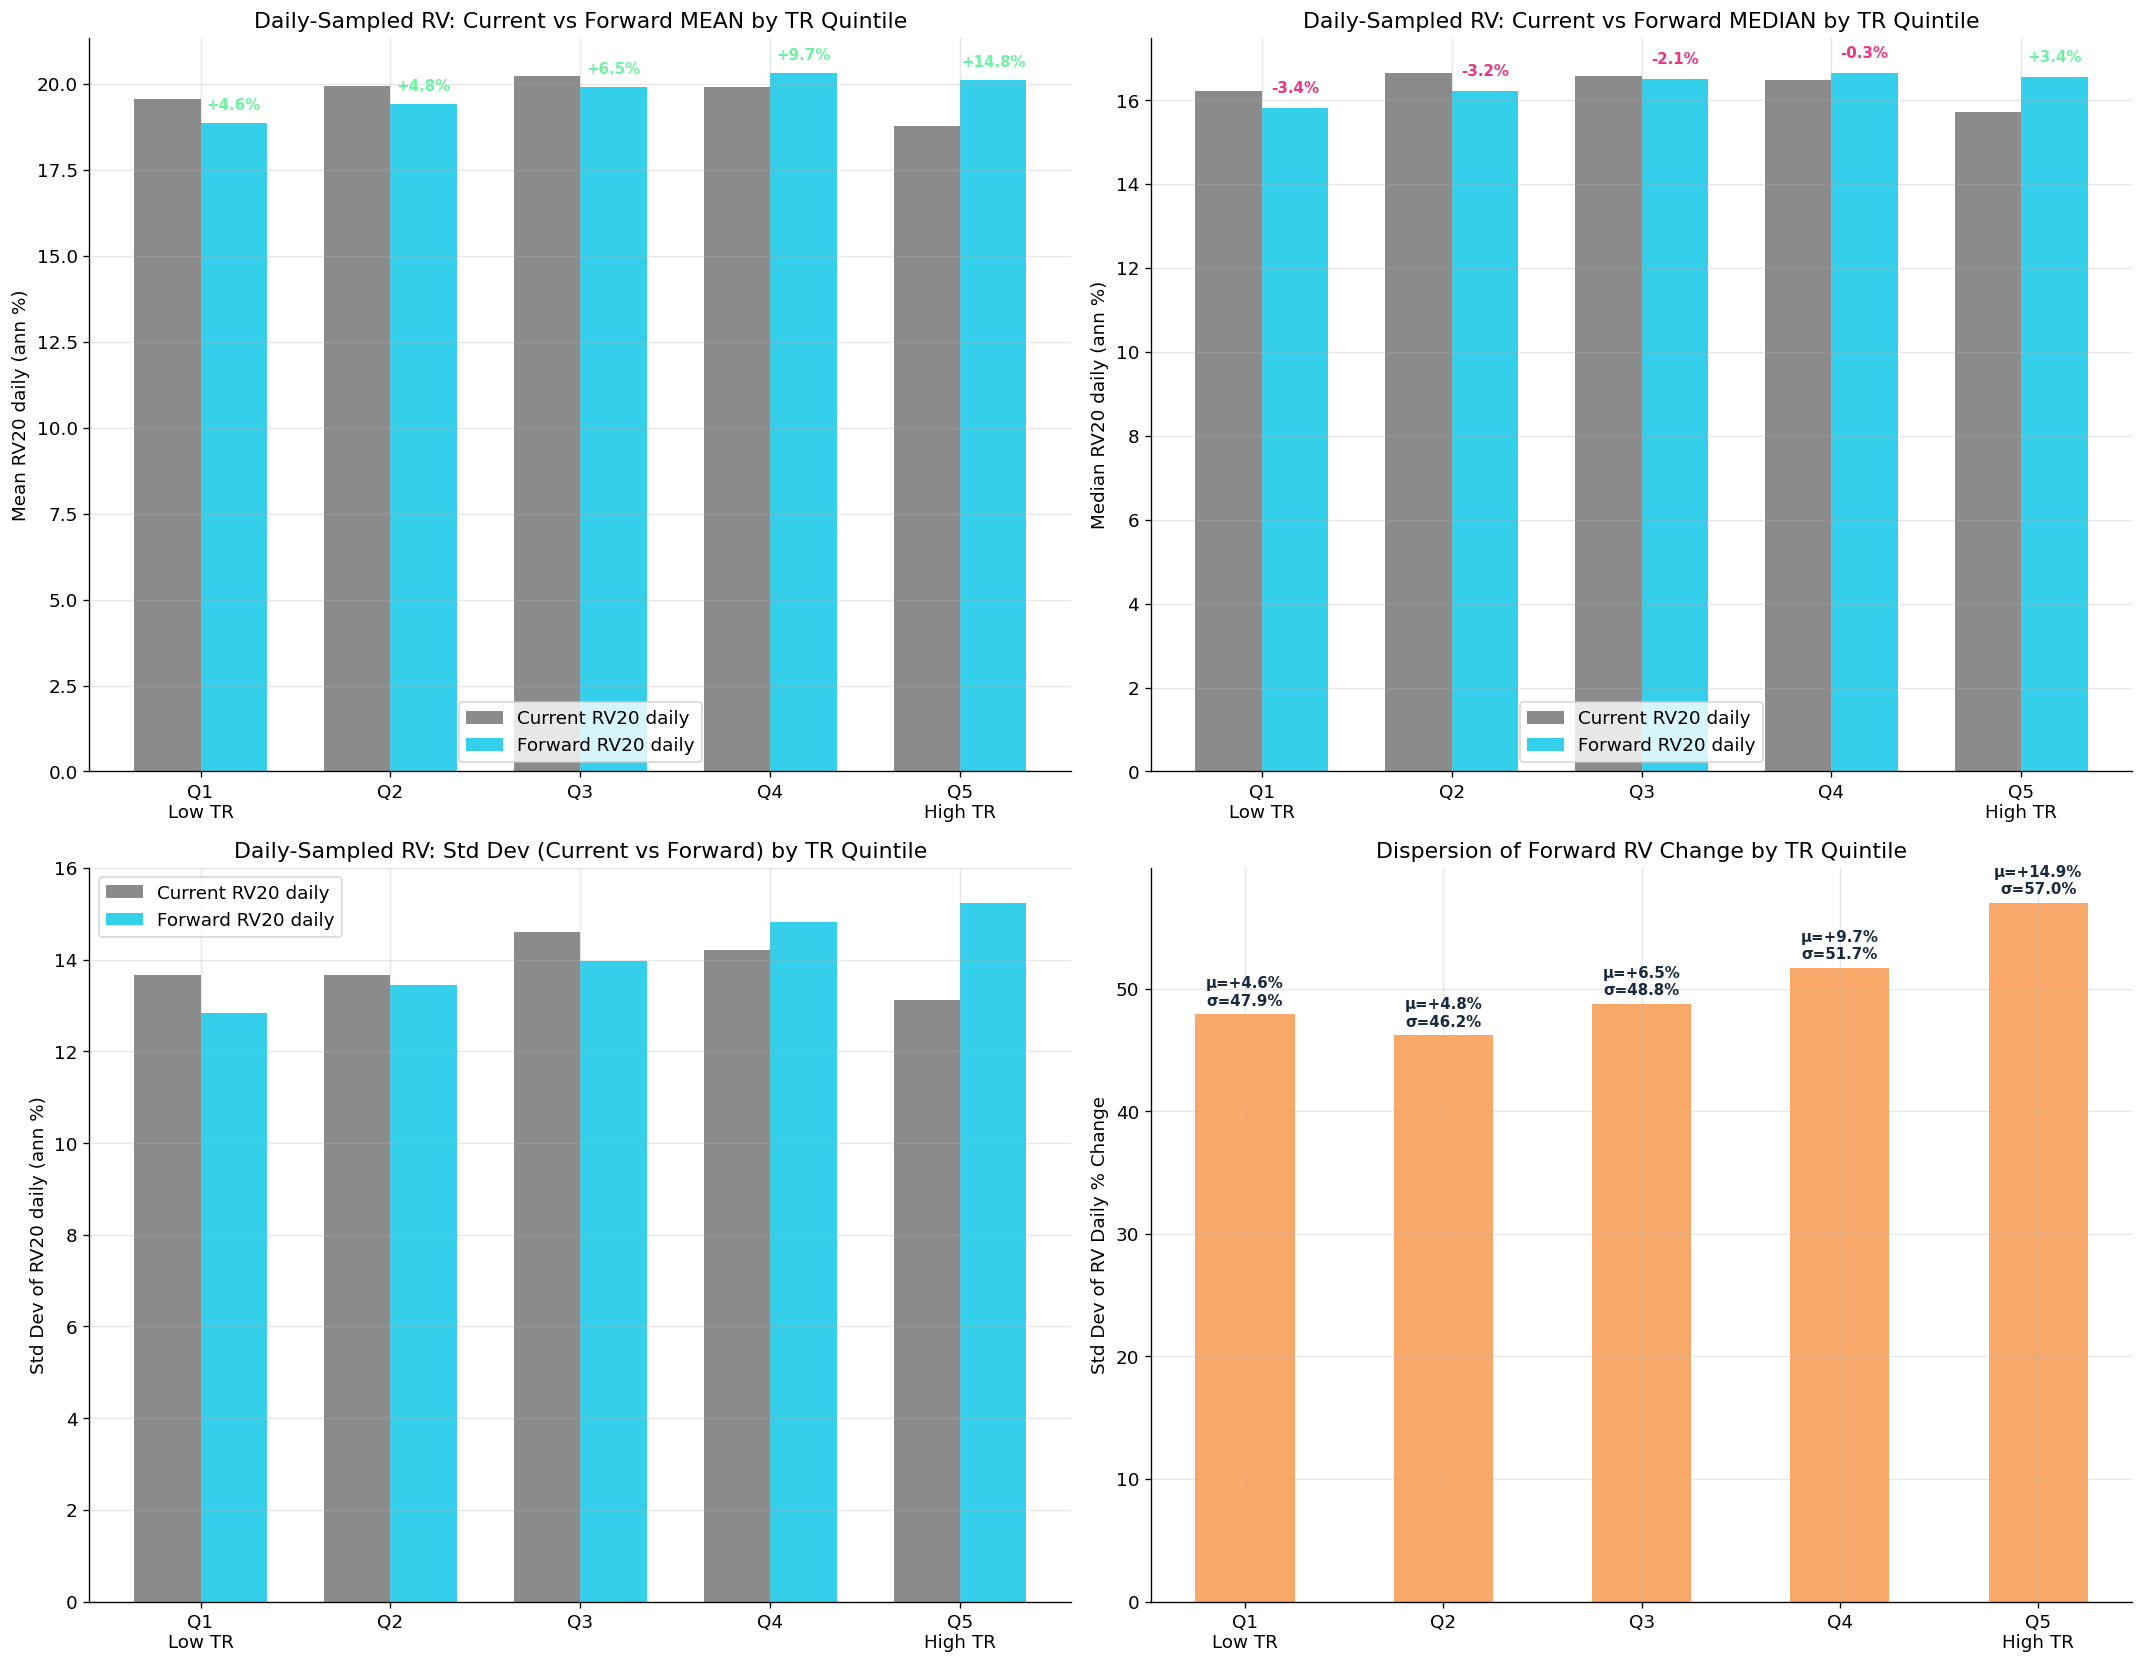

In [ ]:
quintiles = ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── Panel 1: Mean forward RV (daily) — current vs forward ──
ax = axes[0, 0]
x = np.arange(len(quintiles))
w = 0.35
cur_vals = [fwd[fwd.TR_q == q]['rv20_daily'].mean() for q in quintiles]
fwd_vals = [fwd[fwd.TR_q == q]['fwd_rv20_daily'].mean() for q in quintiles]

bars1 = ax.bar(x - w/2, cur_vals, w, label='Current RV20 daily', color=COLORS['neutral'], alpha=0.7)
bars2 = ax.bar(x + w/2, fwd_vals, w, label='Forward RV20 daily', color=COLORS['primary'], alpha=0.8)

for i, q in enumerate(quintiles):
    pct = fwd_by_tr.loc[q, 'rv_daily_chg_mean']
    color = COLORS['green'] if pct > 0 else COLORS['pink']
    ax.text(x[i] + w/2, fwd_vals[i] + 0.3, f'{pct:+.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(['Q1\nLow TR', 'Q2', 'Q3', 'Q4', 'Q5\nHigh TR'])
ax.set_ylabel('Mean RV20 daily (ann %)')
ax.set_title('Daily-Sampled RV: Current vs Forward MEAN by TR Quintile')
ax.legend()

# ── Panel 2: Median forward RV (daily) — current vs forward ──
ax = axes[0, 1]
cur_meds = [fwd[fwd.TR_q == q]['rv20_daily'].median() for q in quintiles]
fwd_meds = [fwd[fwd.TR_q == q]['fwd_rv20_daily'].median() for q in quintiles]

bars1 = ax.bar(x - w/2, cur_meds, w, label='Current RV20 daily', color=COLORS['neutral'], alpha=0.7)
bars2 = ax.bar(x + w/2, fwd_meds, w, label='Forward RV20 daily', color=COLORS['primary'], alpha=0.8)

for i, q in enumerate(quintiles):
    pct = fwd_by_tr.loc[q, 'rv_daily_chg_med']
    color = COLORS['green'] if pct > 0 else COLORS['pink']
    ax.text(x[i] + w/2, fwd_meds[i] + 0.3, f'{pct:+.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(['Q1\nLow TR', 'Q2', 'Q3', 'Q4', 'Q5\nHigh TR'])
ax.set_ylabel('Median RV20 daily (ann %)')
ax.set_title('Daily-Sampled RV: Current vs Forward MEDIAN by TR Quintile')
ax.legend()

# ── Panel 3: Std Dev of forward RV by quintile ──
ax = axes[1, 0]
cur_stds = [fwd[fwd.TR_q == q]['rv20_daily'].std() for q in quintiles]
fwd_stds = [fwd[fwd.TR_q == q]['fwd_rv20_daily'].std() for q in quintiles]

bars1 = ax.bar(x - w/2, cur_stds, w, label='Current RV20 daily', color=COLORS['neutral'], alpha=0.7)
bars2 = ax.bar(x + w/2, fwd_stds, w, label='Forward RV20 daily', color=COLORS['primary'], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['Q1\nLow TR', 'Q2', 'Q3', 'Q4', 'Q5\nHigh TR'])
ax.set_ylabel('Std Dev of RV20 daily (ann %)')
ax.set_title('Daily-Sampled RV: Std Dev (Current vs Forward) by TR Quintile')
ax.legend()

# ── Panel 4: Std Dev of % change in RV by quintile ──
ax = axes[1, 1]
chg_stds = [fwd[fwd.TR_q == q]['rv_daily_pct_chg'].std() for q in quintiles]
chg_means = [fwd[fwd.TR_q == q]['rv_daily_pct_chg'].mean() for q in quintiles]

ax.bar(x, chg_stds, 0.5, color=COLORS['secondary'], alpha=0.7)

for i in range(len(quintiles)):
    ax.text(x[i], chg_stds[i] + 0.5, f'μ={chg_means[i]:+.1f}%\nσ={chg_stds[i]:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['accent'])

ax.set_xticks(x)
ax.set_xticklabels(['Q1\nLow TR', 'Q2', 'Q3', 'Q4', 'Q5\nHigh TR'])
ax.set_ylabel('Std Dev of RV Daily % Change')
ax.set_title('Dispersion of Forward RV Change by TR Quintile')

plt.tight_layout()
plt.show()

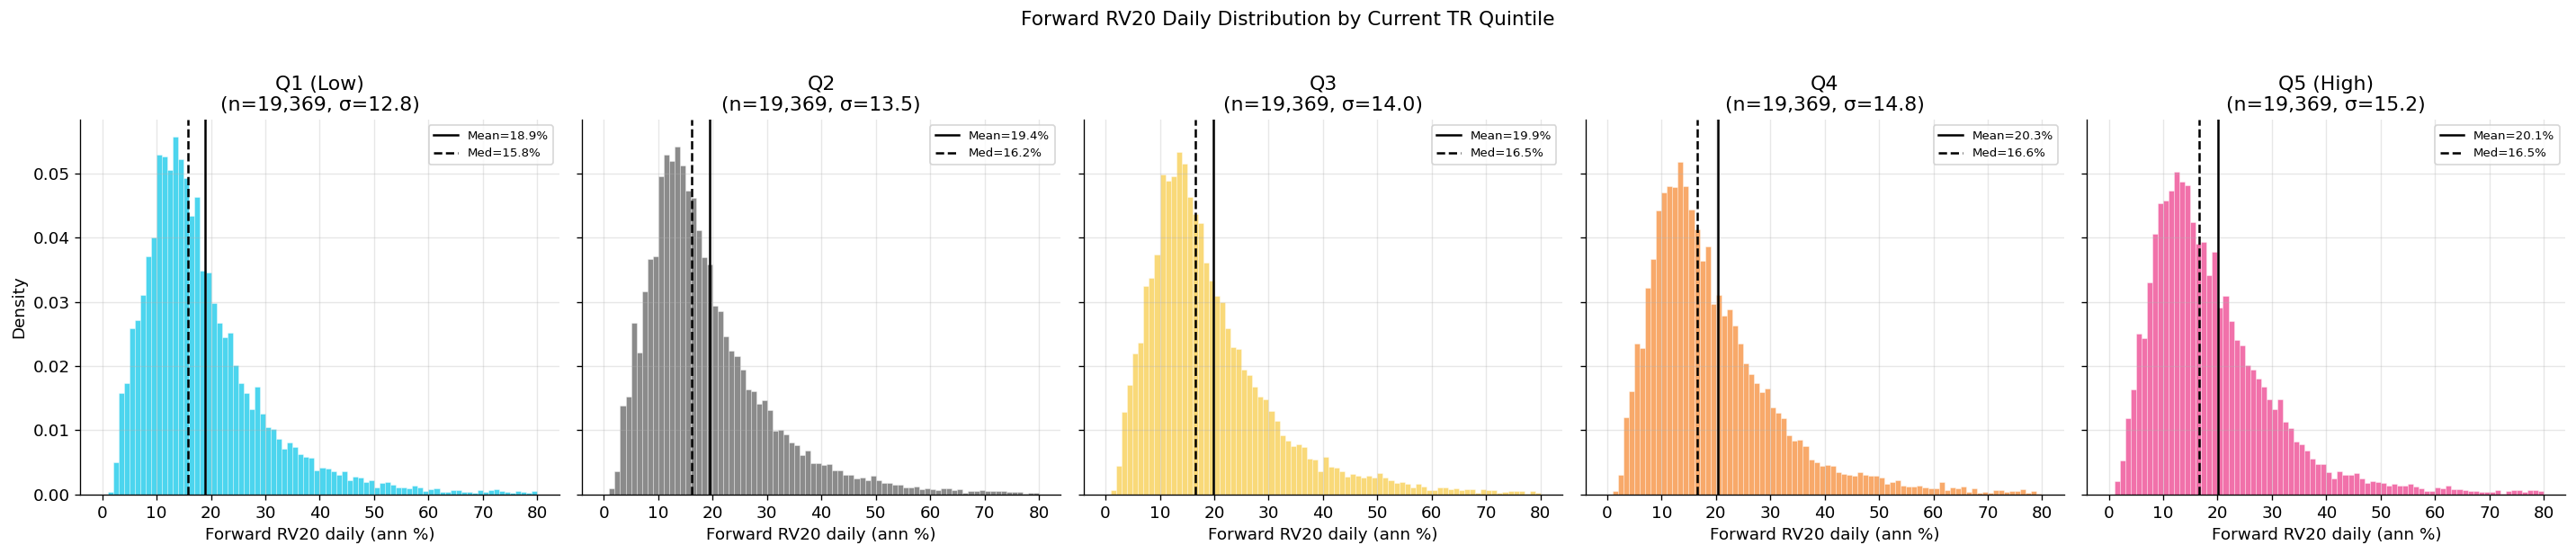

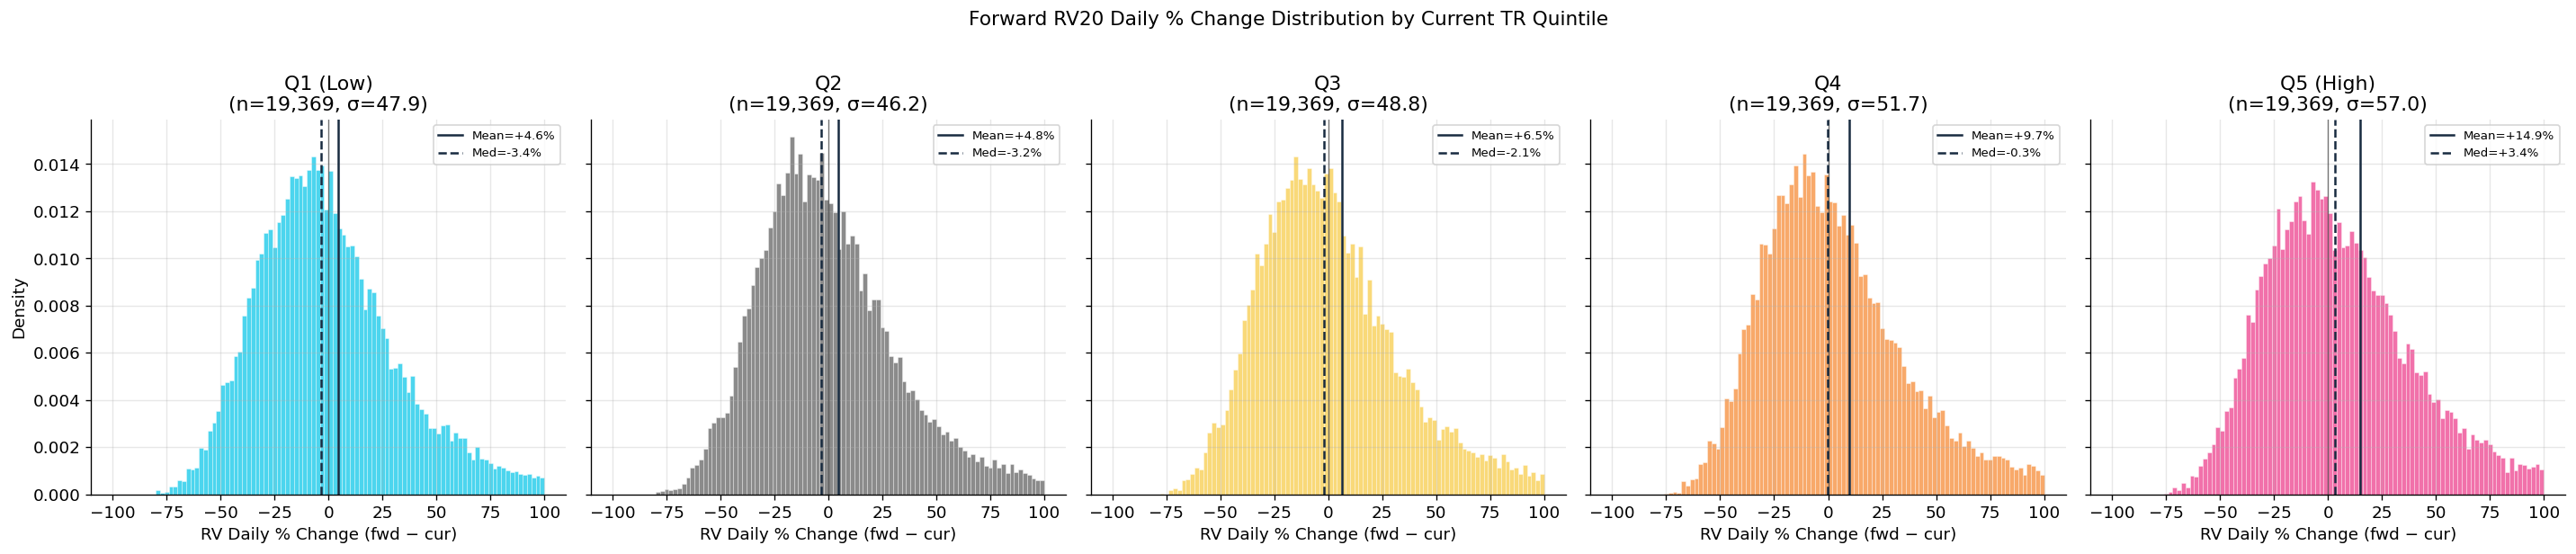

In [ ]:
# Histogram of forward RV20 daily by TR quintile
fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True, sharex=True)
q_colors = [COLORS['primary'], COLORS['neutral'], COLORS['gold'], COLORS['secondary'], COLORS['pink']]

for i, (q, c) in enumerate(zip(quintiles, q_colors)):
    ax = axes[i]
    data = fwd[fwd.TR_q == q]['fwd_rv20_daily']
    ax.hist(data, bins=80, range=(0, 80), color=c, alpha=0.7,
            edgecolor='white', linewidth=0.3, density=True)
    
    m = data.mean()
    med = data.median()
    s = data.std()
    
    ax.axvline(m, color='black', ls='-', lw=1.5, label=f'Mean={m:.1f}%')
    ax.axvline(med, color='black', ls='--', lw=1.5, label=f'Med={med:.1f}%')
    
    ax.set_title(f'{q}\n(n={len(data):,}, σ={s:.1f})')
    ax.set_xlabel('Forward RV20 daily (ann %)')
    if i == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Forward RV20 Daily Distribution by Current TR Quintile', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Histogram of % change in RV by TR quintile
fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True, sharex=True)

for i, (q, c) in enumerate(zip(quintiles, q_colors)):
    ax = axes[i]
    data = fwd[fwd.TR_q == q]['rv_daily_pct_chg']
    ax.hist(data, bins=100, range=(-100, 100), color=c, alpha=0.7,
            edgecolor='white', linewidth=0.3, density=True)
    
    m = data.mean()
    med = data.median()
    s = data.std()
    
    ax.axvline(0, color='black', ls='-', lw=0.8, alpha=0.5)
    ax.axvline(m, color=COLORS['accent'], ls='-', lw=1.5, label=f'Mean={m:+.1f}%')
    ax.axvline(med, color=COLORS['accent'], ls='--', lw=1.5, label=f'Med={med:+.1f}%')
    
    ax.set_title(f'{q}\n(n={len(data):,}, σ={s:.1f})')
    ax.set_xlabel('RV Daily % Change (fwd − cur)')
    if i == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Forward RV20 Daily % Change Distribution by Current TR Quintile', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Regime Classification

- **TR threshold:** 1.0
- **VCR threshold:** Per-ticker median


In [ ]:
vcr_medians = panel.groupby('ticker')['vcr20'].median().rename('vcr_median')
panel = panel.merge(vcr_medians, on='ticker', how='left')

def classify_regime(row):
    high_tr  = row['TR'] >= 1.0
    high_vcr = row['vcr20'] > row['vcr_median']
    if high_tr and not high_vcr:  return 'Grinding Trend'
    elif high_tr and high_vcr:    return 'Spike Trend'
    elif not high_tr and not high_vcr: return 'Choppy Grind'
    else:                         return 'Spike Revert'

panel['regime'] = panel.apply(classify_regime, axis=1)

# Propagate to fwd dataframe
fwd = fwd.drop(columns=['vcr_median', 'regime'], errors='ignore')
fwd = fwd.merge(panel[['ticker', 'date', 'vcr_median', 'regime']], on=['ticker', 'date'], how='left')

print("Regime Distribution:\n")
for r in ['Grinding Trend', 'Spike Trend', 'Choppy Grind', 'Spike Revert']:
    n = (panel.regime == r).sum()
    print(f"  {r:20s}: {n:>6,} ({n/len(panel)*100:>5.1f}%)")
print(f"  {'TOTAL':20s}: {len(panel):>6,}")


Regime Distribution:

  Grinding Trend      : 20,744 ( 21.3%)
  Spike Trend         : 21,605 ( 22.1%)
  Choppy Grind        : 28,046 ( 28.8%)
  Spike Revert        : 27,150 ( 27.8%)
  TOTAL               : 97,545


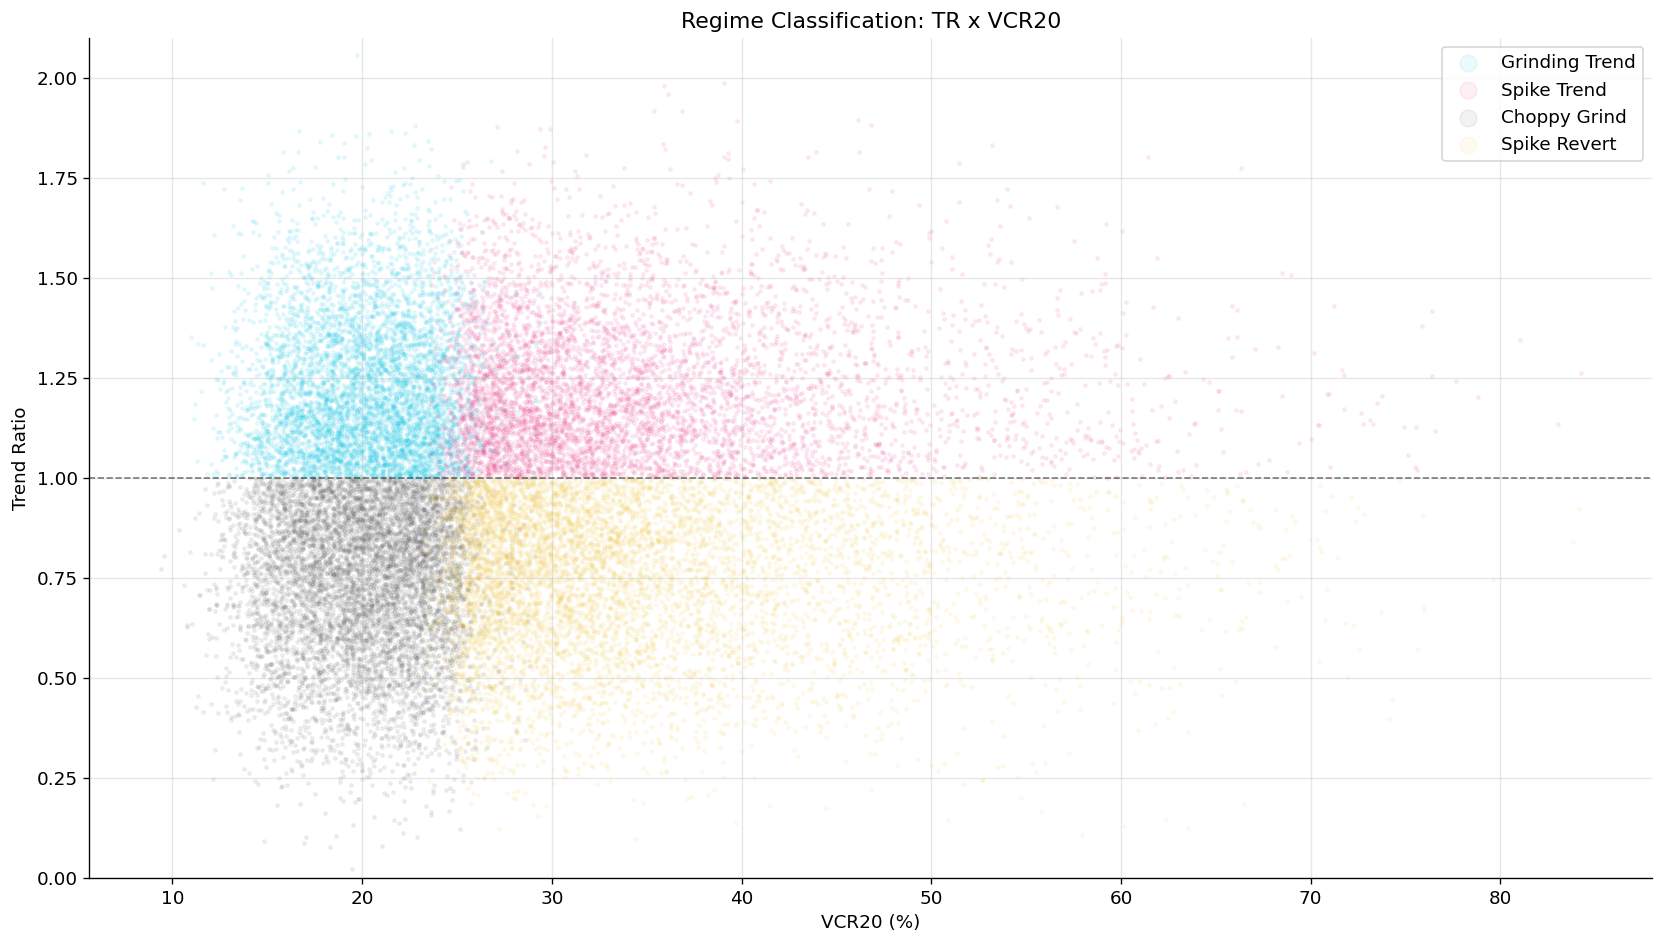

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
sample = panel.sample(n=min(25_000, len(panel)), random_state=42)
for regime, color in REGIME_COLORS.items():
    mask = sample.regime == regime
    ax.scatter(sample.loc[mask, 'vcr20'], sample.loc[mask, 'TR'],
               alpha=0.08, s=4, color=color, label=regime)
ax.axhline(1.0, color='black', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('VCR20 (%)')
ax.set_ylabel('Trend Ratio')
ax.set_title('Regime Classification: TR x VCR20')
ax.set_ylim(0, 2.1)
ax.legend(loc='upper right', markerscale=5)
plt.tight_layout()
plt.show()


## 11. Regime Profiles

In [ ]:
regime_order = ['Grinding Trend', 'Spike Trend', 'Choppy Grind', 'Spike Revert']

regime_summary = panel.groupby('regime').agg(
    obs=('TR', 'count'),
    TR_med=('TR', 'median'),
    VCR_med=('vcr20', 'median'),
    RV20d_med=('rv20_daily', 'median'),
    RV20w_med=('rv20_weekly', 'median'),
).reindex(regime_order).round(2)

print(regime_summary.to_string())


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, regime in enumerate(regime_order):
    ax = axes[i]
    data = panel[panel.regime == regime]['rv20_daily']
    ax.hist(data, bins=80, range=(0, 80), color=REGIME_COLORS[regime],
            alpha=0.7, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(f'{regime}\n(n={len(data):,})')
    ax.set_xlabel('RV20 daily (ann %)')
    if i == 0: ax.set_ylabel('Density')
    ax.axvline(data.median(), color='black', ls='--', lw=1, label=f'Med={data.median():.1f}')
    ax.legend(fontsize=8)
plt.suptitle('RV20 Daily Distribution by Regime', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 12. Forward RV Change — Conditioned on Top 2 TR Quintiles

For observations in Q4 and Q5 of the TR distribution (the trending regimes), what does the distribution of next-period RV changes look like?

This isolates the practical question: when you observe an elevated TR, how much should you expect realized vol to move in the next 20 days?


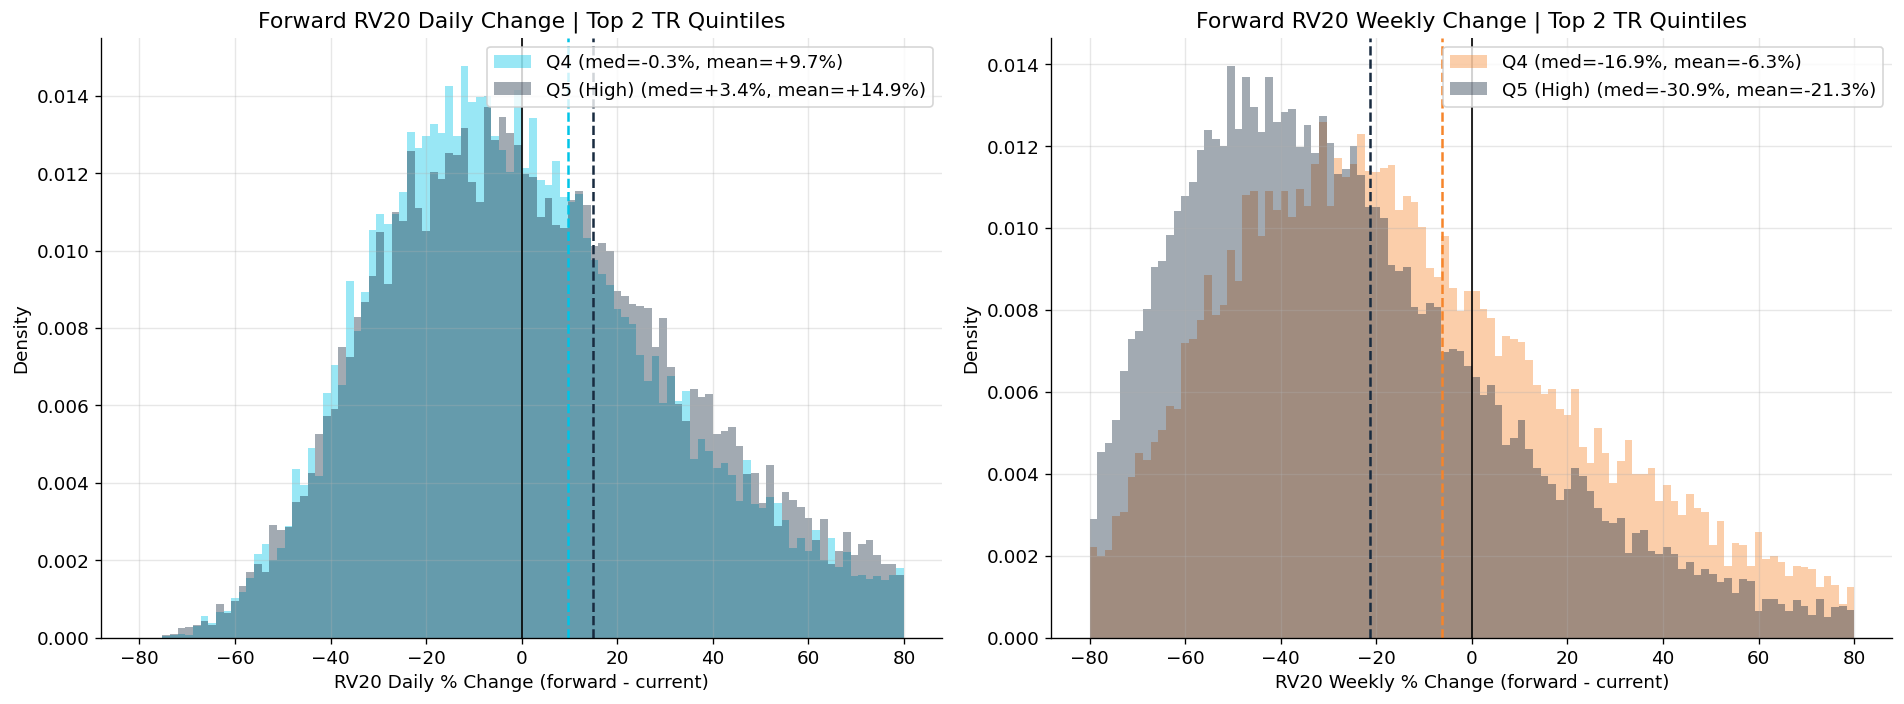


Summary: Forward RV % Change for Top 2 TR Quintiles

  Q4:
    RV daily  pct chg: mean=+9.7%, med=-0.3%
    RV weekly pct chg: mean=-6.3%, med=-16.9%
    % of obs where fwd RV daily > current: 49.6%
    % of obs where fwd RV weekly > current: 34.9%

  Q5 (High):
    RV daily  pct chg: mean=+14.9%, med=+3.4%
    RV weekly pct chg: mean=-21.3%, med=-30.9%
    % of obs where fwd RV daily > current: 53.7%
    % of obs where fwd RV weekly > current: 22.7%



In [ ]:
top2 = fwd[fwd['TR_q'].isin(['Q4', 'Q5 (High)'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Daily RV % change for Q4 and Q5
ax = axes[0]
for q, color, ls in [('Q4', COLORS['primary'], '-'), ('Q5 (High)', COLORS['accent'], '-')]:
    data = top2[top2.TR_q == q]['rv_daily_pct_chg']
    ax.hist(data, bins=100, range=(-80, 80), alpha=0.4, density=True,
            color=color, label=f'{q} (med={data.median():+.1f}%, mean={data.mean():+.1f}%)')
    ax.axvline(data.mean(), color=color, ls='--', lw=1.5)

ax.axvline(0, color='black', ls='-', lw=1)
ax.set_xlabel('RV20 Daily % Change (forward - current)')
ax.set_ylabel('Density')
ax.set_title('Forward RV20 Daily Change | Top 2 TR Quintiles')
ax.legend()

# -- Weekly RV % change for Q4 and Q5
ax = axes[1]
for q, color, ls in [('Q4', COLORS['secondary'], '-'), ('Q5 (High)', COLORS['accent'], '-')]:
    data = top2[top2.TR_q == q]['rv_weekly_pct_chg']
    ax.hist(data, bins=100, range=(-80, 80), alpha=0.4, density=True,
            color=color, label=f'{q} (med={data.median():+.1f}%, mean={data.mean():+.1f}%)')
    ax.axvline(data.mean(), color=color, ls='--', lw=1.5)

ax.axvline(0, color='black', ls='-', lw=1)
ax.set_xlabel('RV20 Weekly % Change (forward - current)')
ax.set_ylabel('Density')
ax.set_title('Forward RV20 Weekly Change | Top 2 TR Quintiles')
ax.legend()

plt.tight_layout()
plt.show()

# Summary table
print("\nSummary: Forward RV % Change for Top 2 TR Quintiles\n")
for q in ['Q4', 'Q5 (High)']:
    sub = top2[top2.TR_q == q]
    print(f"  {q}:")
    print(f"    RV daily  pct chg: mean={sub.rv_daily_pct_chg.mean():+.1f}%, med={sub.rv_daily_pct_chg.median():+.1f}%")
    print(f"    RV weekly pct chg: mean={sub.rv_weekly_pct_chg.mean():+.1f}%, med={sub.rv_weekly_pct_chg.median():+.1f}%")
    print(f"    % of obs where fwd RV daily > current: {(sub.rv_daily_pct_chg > 0).mean()*100:.1f}%")
    print(f"    % of obs where fwd RV weekly > current: {(sub.rv_weekly_pct_chg > 0).mean()*100:.1f}%")
    print()


## 13. TR × VCR Heatmap — Forward RV Premium/Discount

Each cell shows the **median percent change** in RV20 daily from the current 20-day window to the next: `(fwd_rv - current_rv) / current_rv × 100`.

- **Positive values (green):** forward vol is *higher* than current vol — the market is getting more volatile
- **Negative values (red):** forward vol is *lower* — vol is mean-reverting down
- **The upper-right quadrant** (high TR, high VCR) is where spike-driven trends live
- **High TR, low VCR** is the grinding trend zone — does vol rise or fall after a quiet grind?


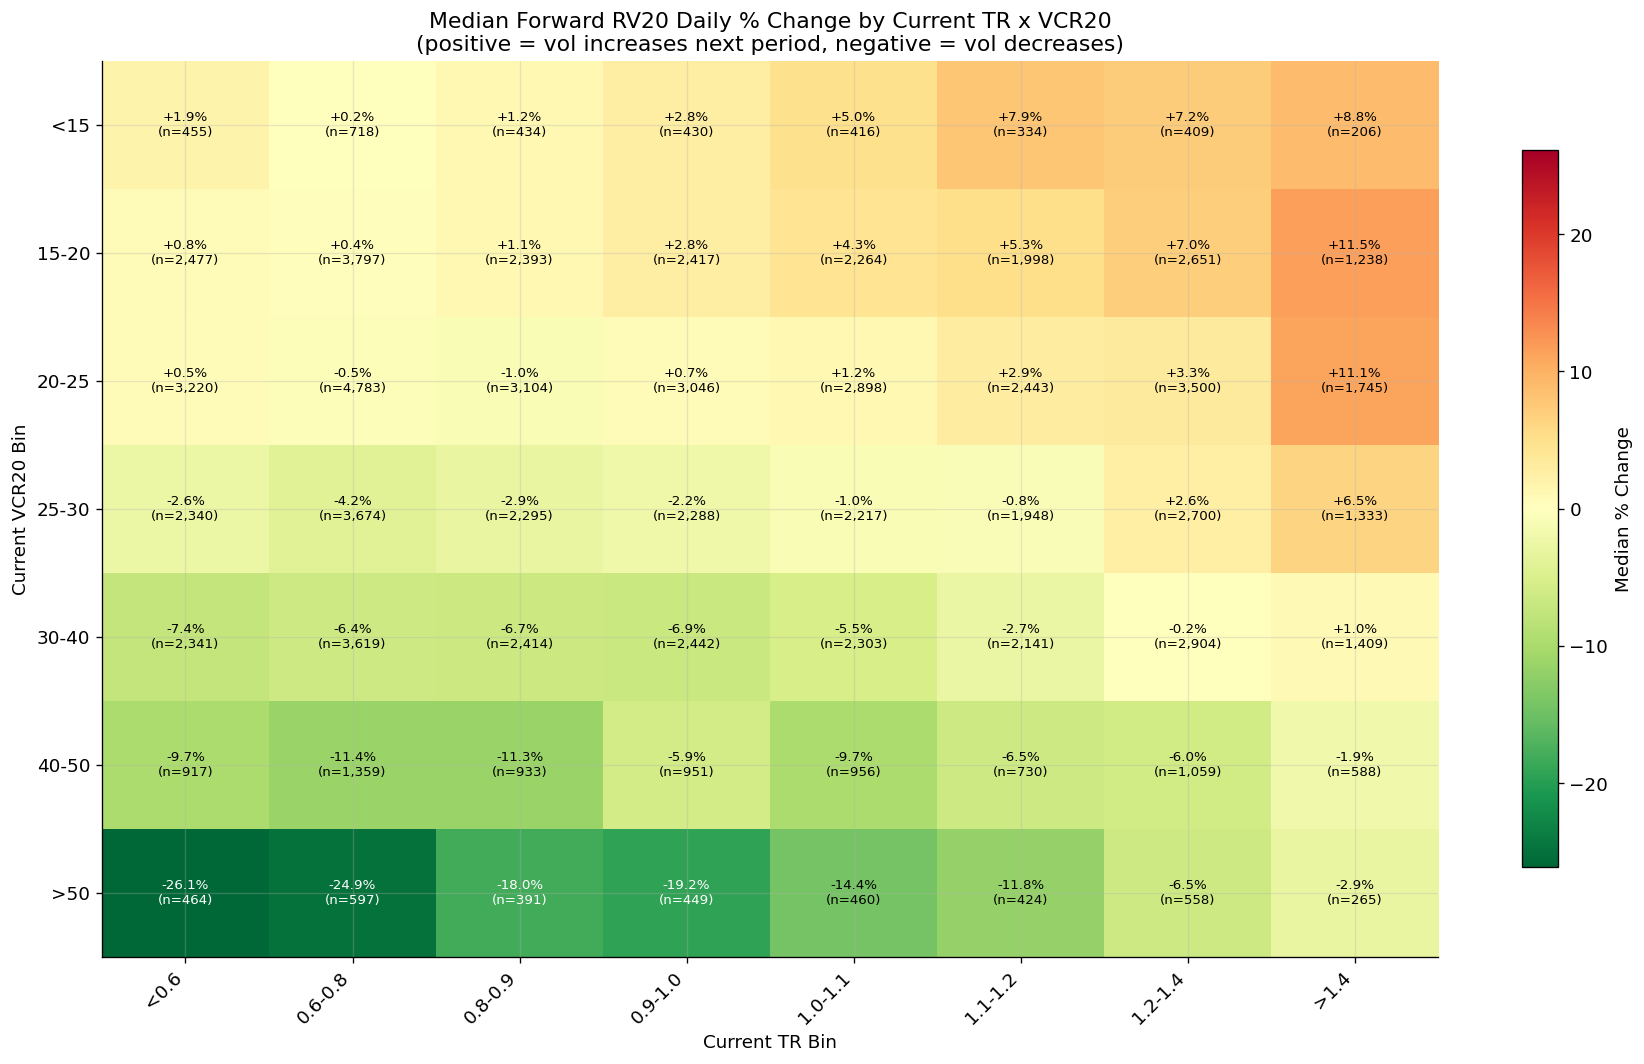

In [ ]:
fwd['TR_bin'] = pd.cut(fwd['TR'],
    bins=[0, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 2.1],
    labels=['<0.6', '0.6-0.8', '0.8-0.9', '0.9-1.0', '1.0-1.1', '1.1-1.2', '1.2-1.4', '>1.4'])

fwd['VCR_bin'] = pd.cut(fwd['vcr20'],
    bins=[0, 15, 20, 25, 30, 40, 50, 100],
    labels=['<15', '15-20', '20-25', '25-30', '30-40', '40-50', '>50'])

# Pivot: median % change in forward RV daily
pivot_pct = fwd.pivot_table(
    values='rv_daily_pct_chg', index='VCR_bin', columns='TR_bin', aggfunc='median'
).round(1)
counts = fwd.pivot_table(
    values='rv_daily_pct_chg', index='VCR_bin', columns='TR_bin', aggfunc='count'
)

fig, ax = plt.subplots(figsize=(15, 9))

vals = pivot_pct.values
# Center the colormap on 0
vmax = max(abs(np.nanmin(vals)), abs(np.nanmax(vals)))
im = ax.imshow(vals, cmap='RdYlGn_r', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(pivot_pct.index)):
    for j in range(len(pivot_pct.columns)):
        v = vals[i, j]
        n = counts.values[i, j]
        if not np.isnan(v):
            color = 'white' if abs(v) > vmax * 0.6 else 'black'
            sign = '+' if v > 0 else ''
            ax.text(j, i, f'{sign}{v:.1f}%\n(n={int(n):,})',
                    ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(pivot_pct.columns)))
ax.set_xticklabels(pivot_pct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_pct.index)))
ax.set_yticklabels(pivot_pct.index)
ax.set_xlabel('Current TR Bin')
ax.set_ylabel('Current VCR20 Bin')
ax.set_title('Median Forward RV20 Daily % Change by Current TR x VCR20\n'
             '(positive = vol increases next period, negative = vol decreases)')
plt.colorbar(im, shrink=0.8, label='Median % Change')

plt.tight_layout()
plt.show()


## 14. Export

In [ ]:
output_path = 'etf_vol_ratio_panel.csv'
panel.to_csv(output_path, index=False)
print(f"Panel exported to {output_path}")
print(f"  {panel.shape[0]:,} rows x {panel.shape[1]} cols")
